# Silicon, part 2: the self-consistent field and the band structure

Part 1 built the plane-wave basis. This notebook does the physics: read the
pseudopotential, converge the electron density, and compute the band structure — checking
every number against the Quantum ESPRESSO output committed alongside the same input.

The headline: **silicon's total energy comes out within 1.1e-8 Ry of QE**, term by term,
and its band structure within 0.0002 eV.

**What this covers:** phases P3–P7 (pseudopotentials, the Hamiltonian, the SCF loop,
symmetry, bands). Still missing: an iterative eigensolver, k-point reduction, density of
states, and spin.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso.io import read_qe_output
from pypresso.io.pwin import read_pw_input
from pypresso.pseudo import read_upf
from pypresso.scf import run_scf
from pypresso.system import build_system
from pypresso.workflows import run_bands

QE = Path("../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite/pw_scf")
PSEUDO = Path("../tests/data/pseudo")

system = build_system(read_pw_input(QE / "scf.in"))
pseudos = tuple(read_upf(PSEUDO / s.pseudo_file) for s in system.structure.species)
print(pseudos[0])

Pseudopotential(Si, NC, Z=4, 2 projectors (l=[0, 1]), mesh 431 (msh 357), SLA  PZ   NOGX NOGC)


## 1. What is in a pseudopotential

A pseudopotential replaces the nucleus and the core electrons with something smooth enough
to expand in plane waves. The UPF file tabulates it on a logarithmic radial grid:

* `PP_LOCAL` — the **local** potential, felt by every angular momentum channel. It goes as
  `-Z e^2 / r` far out, which is why its Fourier transform needs care.
* `PP_BETA` — the **projectors** of the nonlocal part, which acts differently on s and p
  electrons. That difference is what makes the pseudopotential reproduce the right
  scattering.
* `PP_RHOATOM` — the atomic charge density, used to start the SCF from something sensible.

Silicon here has one s and one p projector, on a 431-point mesh.

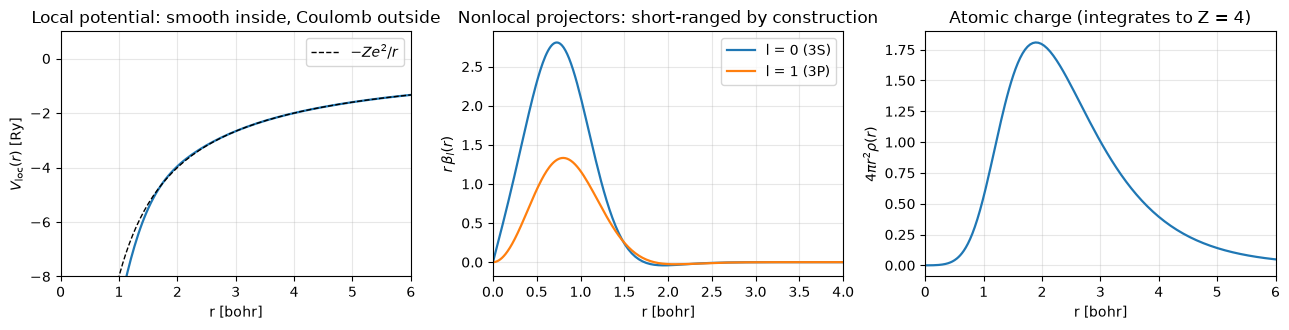

In [2]:
si = pseudos[0]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

axes[0].plot(si.r, si.vloc, lw=1.6)
axes[0].plot(si.r, -2 * si.z_valence / np.maximum(si.r, 1e-3), "k--", lw=1,
             label=r"$-Z e^2/r$")
axes[0].set_xlim(0, 6); axes[0].set_ylim(-8, 1)
axes[0].set_xlabel("r [bohr]"); axes[0].set_ylabel(r"$V_{\rm loc}(r)$ [Ry]")
axes[0].set_title("Local potential: smooth inside, Coulomb outside")
axes[0].legend(); axes[0].grid(alpha=0.3)

for projector in si.projectors:
    axes[1].plot(si.r, projector.beta, lw=1.6, label=f"l = {projector.l} ({projector.label})")
axes[1].set_xlim(0, 4)
axes[1].set_xlabel("r [bohr]"); axes[1].set_ylabel(r"$r\,\beta_l(r)$")
axes[1].set_title("Nonlocal projectors: short-ranged by construction")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(si.r, si.rho_atom, lw=1.6)
axes[2].set_xlim(0, 6)
axes[2].set_xlabel("r [bohr]"); axes[2].set_ylabel(r"$4\pi r^2 \rho(r)$")
axes[2].set_title(f"Atomic charge (integrates to Z = {si.z_valence:g})")
axes[2].grid(alpha=0.3)
fig.tight_layout()

### Into reciprocal space

A plane-wave code never sees these radial functions: it needs their transforms at each
$|G|$. Two of them have a subtlety worth knowing about.

$V_{\rm loc}(q)$ is the transform of a function with a $-Ze^2/r$ tail, so it diverges as
$1/q^2$ and cannot be integrated numerically as it stands. The trick — QE's, reproduced
here — is to add $Ze^2\,\mathrm{erf}(r)/r$ inside the integral, making the integrand
short-ranged, and subtract that function's analytic transform outside it.

**The $G=0$ term is not the $q\to0$ limit of that expression.** It uses $Ze^2$ where the
rest uses $Ze^2\,\mathrm{erf}(r)$, and QE's source says so in a comment. Using the wrong one
shifts every eigenvalue in the calculation by a constant — 2.5 eV for silicon — while the
SCF converges just as smoothly as before. It cost an afternoon.

V_loc(G=0) = -0.01853306 Ry


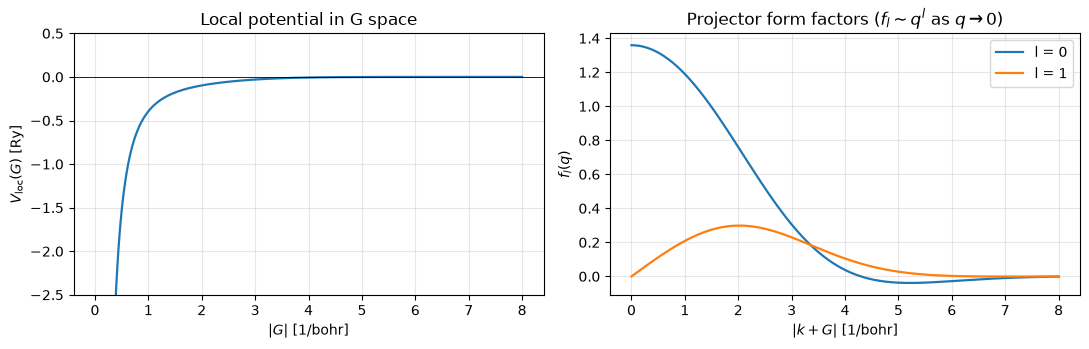

In [3]:
from pypresso.pseudo import local_potential_of_g, projector_form_factors
from pypresso.basis.builder import build_basis

basis = build_basis(system)
omega = float(system.cell.volume)
q = np.linspace(1e-6, 8.0, 400)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].plot(q, np.asarray(local_potential_of_g(si, q, omega)), lw=1.6)
axes[0].axhline(0, color="k", lw=0.6)
axes[0].set_xlabel(r"$|G|$ [1/bohr]"); axes[0].set_ylabel(r"$V_{\rm loc}(G)$ [Ry]")
axes[0].set_title("Local potential in G space")
axes[0].set_ylim(-2.5, 0.5); axes[0].grid(alpha=0.3)

factors = np.asarray(projector_form_factors(si, q, omega))
for row, projector in zip(factors, si.projectors):
    axes[1].plot(q, row, lw=1.6, label=f"l = {projector.l}")
axes[1].set_xlabel(r"$|k+G|$ [1/bohr]"); axes[1].set_ylabel(r"$f_l(q)$")
axes[1].set_title(r"Projector form factors ($f_l \sim q^l$ as $q\to0$)")
axes[1].legend(); axes[1].grid(alpha=0.3)
fig.tight_layout()

print("V_loc(G=0) = %.8f Ry" % float(local_potential_of_g(si, np.array([0.0]), omega)[0]))

## 2. Symmetry, and why it cannot be skipped

`scf.in` samples the Brillouin zone with two special points. Those two stand in for the
whole zone *because of symmetry* — and the density built from them alone does not have the
symmetry of the crystal. QE restores it explicitly, and so must we.

Skipping this step does not produce an obvious failure. The SCF converges, the energy looks
plausible, and only two things give it away: the total is wrong in the third decimal, and
levels that should be exactly degenerate are split by tens of meV.

Diamond silicon is also **non-symmorphic**: half its 48 operations involve a fractional
translation of (¾,¾,¾), because the two atoms in the cell are related by one. A symmetry
search that only looks for pure rotations finds 24 of them.

In [4]:
from pypresso.system.symmetry import find_symmetries, lattice_point_group

lattice_group = lattice_point_group(np.asarray(system.cell.at))
symmetries = find_symmetries(system.cell, system.structure)

print(f"point group of the fcc lattice : {len(lattice_group)} operations")
print(f"space group of diamond silicon : {symmetries.nsym} operations")
print(f"symmorphic (no translations)   : {symmetries.symmorphic}")

translations = symmetries.translation_array()
unique = np.unique(np.round(translations, 6), axis=0)
print(f"distinct fractional translations: {[tuple(t) for t in unique]}")

point group of the fcc lattice : 48 operations
space group of diamond silicon : 48 operations
symmorphic (no translations)   : False
distinct fractional translations: [(np.float64(0.0), np.float64(0.0), np.float64(0.0)), (np.float64(0.75), np.float64(0.75), np.float64(0.75))]


## 3. The self-consistent field

The loop is short to describe and is the whole of density functional theory in practice:

1. build the potential from the current density — Hartree, exchange-correlation, and the
   fixed local pseudopotential;
2. diagonalise the Hamiltonian at each k-point;
3. build a new density from the occupied states, and symmetrise it;
4. mix the new density into the old one and repeat.

The mixing in step 4 is not a detail. Feeding the output density straight back in diverges:
charge sloshes between regions of the cell, amplified each round by the Hartree term.

In [5]:
result = run_scf(system, pseudos, conv_thr=1e-10, verbose=True)
print(f"\nconverged: {result.converged} in {result.iterations} iterations")

  iteration   1   E =     -15.81246806 Ry   dE = -   |drho| = 3.64e-02


  iteration   2   E =     -15.79468567 Ry   dE = 1.78e-02   |drho| = 6.45e-03
  iteration   3   E =     -15.79449745 Ry   dE = 1.88e-04   |drho| = 7.17e-04


  iteration   4   E =     -15.79449591 Ry   dE = 1.54e-06   |drho| = 2.80e-05
  iteration   5   E =     -15.79449594 Ry   dE = 2.71e-08   |drho| = 1.70e-06


  iteration   6   E =     -15.79449594 Ry   dE = 5.96e-12   |drho| = 5.73e-07

converged: True in 6 iterations


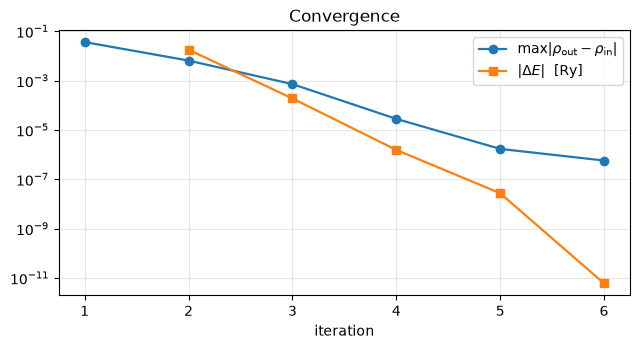

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
iterations = [h["iteration"] for h in result.history]
ax.semilogy(iterations, [h["residual"] for h in result.history], "o-", lw=1.6,
            label=r"$\max|\rho_{\rm out}-\rho_{\rm in}|$")
changes = [(h["iteration"], h["change"]) for h in result.history if h["change"]]
ax.semilogy(*zip(*changes), "s-", lw=1.6, label=r"$|\Delta E|$  [Ry]")
ax.set_xlabel("iteration"); ax.set_title("Convergence")
ax.legend(); ax.grid(alpha=0.3, which="both")
fig.tight_layout()

### The energy, term by term

Comparing only the total would be too forgiving. The total energy is *variational*: it is
second-order accurate in the error of the density, so it can look right while an individual
term is wrong. Comparing the decomposition localises any error to one physical
contribution.

`one-electron` is the kinetic plus external-potential energy. It is assembled as
`eband + deband`: the sum of occupied eigenvalues, which double-counts Hartree and
exchange-correlation, minus exactly that double counting.

In [7]:
reference = read_qe_output(QE / "benchmark.out.git.inp=scf.in")

print("%-16s %18s %18s %12s" % ("term [Ry]", "pypresso", "Quantum ESPRESSO", "difference"))
print("-" * 68)
for term, value in result.energy_terms.items():
    theirs = reference.energy_terms[term]
    print("%-16s %18.8f %18.8f %12.1e" % (term, value, theirs, value - theirs))
print("-" * 68)
print("%-16s %18.8f %18.8f %12.1e" % ("TOTAL", result.total_energy,
                                      reference.total_energy,
                                      result.total_energy - reference.total_energy))
print()
print("eigenvalues [eV]")
for ik, (ours, theirs) in enumerate(zip(result.eigenvalues_ev, reference.eigenvalues[0])):
    print(f"  k{ik+1}  ours {np.array2string(ours, precision=4)}")
    print(f"      QE   {np.array2string(theirs, precision=4)}")
print(f"\nhighest occupied level: {result.homo * 13.605693122994017:.4f} eV"
      f"   (QE {reference.homo:.4f} eV)")

term [Ry]                  pypresso   Quantum ESPRESSO   difference
--------------------------------------------------------------------
one-electron             4.83372322         4.83378641     -6.3e-05
hartree                  1.08438823         1.08429090      9.7e-05
xc                      -4.81284881        -4.81281466     -3.4e-05
ewald                  -16.89975858       -16.89975858      2.8e-09
--------------------------------------------------------------------
TOTAL                  -15.79449594       -15.79449593     -1.1e-08

eigenvalues [eV]
  k1  ours [-4.8705  2.3787  5.5366  5.5366]
      QE   [-4.8701  2.3792  5.5371  5.5371]
  k2  ours [-2.9169 -0.0658  2.6792  4.035 ]
      QE   [-2.9165 -0.0653  2.6795  4.0355]

highest occupied level: 5.5366 eV   (QE 5.5371 eV)


### The converged density

The bonding charge between the two atoms is the physical content of the calculation: this
is the covalent bond of diamond silicon, and it is what the total energy is an integral
over.

integral of rho over the cell = 8.00000000 electrons
density at the bond centre    = 0.0887 electrons/bohr^3
density at the cell minimum   = 0.0034 electrons/bohr^3


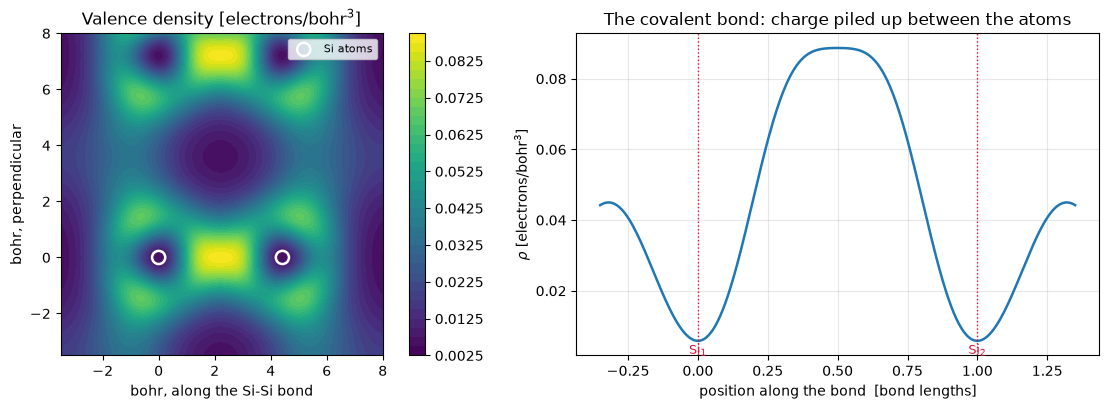

In [8]:
from pypresso.basis.fft import r_to_g

# Evaluate the density exactly at arbitrary points from its Fourier components,
# rather than sampling the 15^3 grid: rho(r) = sum_G rho(G) exp(iG.r). The grid
# holds all the information, but reading it off directly gives a blocky picture.
rho_g = np.asarray(r_to_g(result.density, basis.dense.fft_index))
g_cart = np.asarray(basis.dense.cartesian(system.cell))
tau = np.asarray(system.structure.positions)


def density_at(points):
    return (np.exp(1j * points @ g_cart.T) * rho_g).sum(axis=1).real


# The plane containing both atoms and the bond between them.
bond = tau[1] - tau[0]
e1 = bond / np.linalg.norm(bond)
e2 = np.cross(e1, [0.0, 0.0, 1.0]); e2 /= np.linalg.norm(e2)
span = np.linspace(-3.5, 8.0, 260)
u, v = np.meshgrid(span, span, indexing="ij")
plane = tau[0] + u[..., None] * e1 + v[..., None] * e2
image = density_at(plane.reshape(-1, 3)).reshape(u.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

mesh = axes[0].contourf(span, span, image.T, levels=40, cmap="viridis")
axes[0].scatter([0.0, np.linalg.norm(bond)], [0.0, 0.0], s=90, facecolors="none",
                edgecolors="white", lw=1.8, label="Si atoms")
axes[0].set_aspect("equal")
axes[0].set_xlabel("bohr, along the Si-Si bond"); axes[0].set_ylabel("bohr, perpendicular")
axes[0].set_title(r"Valence density [electrons/bohr$^3$]")
axes[0].legend(loc="upper right", fontsize=8)
fig.colorbar(mesh, ax=axes[0])

line = tau[0] + np.linspace(-0.35, 1.35, 400)[:, None] * bond
axes[1].plot(np.linspace(-0.35, 1.35, 400), density_at(line), lw=1.8)
for position, label in ((0.0, r"Si$_1$"), (1.0, r"Si$_2$")):
    axes[1].axvline(position, color="crimson", ls=":", lw=1)
    axes[1].annotate(label, (position, 0.002), color="crimson", ha="center", fontsize=9)
axes[1].set_xlabel("position along the bond  [bond lengths]")
axes[1].set_ylabel(r"$\rho$ [electrons/bohr$^3$]")
axes[1].set_title("The covalent bond: charge piled up between the atoms")
axes[1].grid(alpha=0.3)
fig.tight_layout()

density = np.asarray(result.density)
print("integral of rho over the cell = %.8f electrons"
      % (density.sum() * float(system.cell.volume) / density.size))
print("density at the bond centre    = %.4f electrons/bohr^3" % density_at((tau[0] + 0.5 * bond)[None])[0])
print("density at the cell minimum   = %.4f electrons/bohr^3" % density.min())

## 4. The band structure

With the density converged, the potential is frozen and the Hamiltonian is diagonalised
along a path through the Brillouin zone. Nothing is self-consistent about this step — which
is exactly why it can use k-points that would make no sense as an integration grid.

The path here is the one in `scf-1.in`: Γ → X → (a zone-boundary segment) → L → Γ, 21
points. The three inputs in that directory run as a sequence sharing one output directory,
so `scf-1.in`'s reference bands belong to precisely the density `scf.in` converges to.

In [9]:
band_system = build_system(read_pw_input(QE / "scf-1.in"))
bands = run_bands(band_system, pseudos, result.density)
band_reference = read_qe_output(QE / "benchmark.out.git.inp=scf-1.in")

ours, theirs = bands.eigenvalues_ev, band_reference.eigenvalues[0]
print("bands: %s   max |difference| from QE: %.5f eV" % (ours.shape, np.abs(ours - theirs).max()))
print("indirect gap: %.4f eV   (LDA underestimates; experiment is ~1.1 eV)" % bands.gap(8))

bands: (21, 8)   max |difference| from QE: 0.00024 eV
indirect gap: 0.4885 eV   (LDA underestimates; experiment is ~1.1 eV)


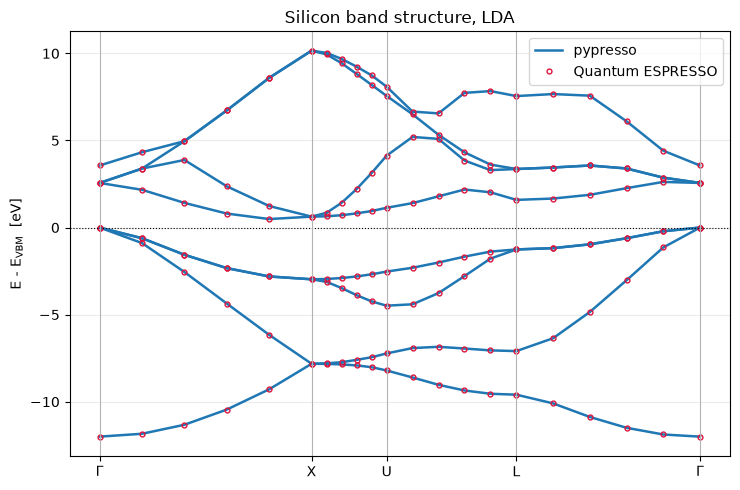

In [10]:
x = bands.path_length
homo = ours[:, 3].max()

fig, ax = plt.subplots(figsize=(7.5, 5))
for band in range(ours.shape[1]):
    ax.plot(x, ours[:, band] - homo, "-", color="C0", lw=1.8,
            label="pypresso" if band == 0 else None)
    ax.plot(x, theirs[:, band] - homo, "o", color="crimson", ms=3.5, mfc="none",
            label="Quantum ESPRESSO" if band == 0 else None)

ax.axhline(0, color="k", lw=0.8, ls=":")
# The path vertices, at every 5th point by construction of the K_POINTS card.
# The third one is (1, 1/4, 1/4) in units of 2*pi/a, which is U rather than K --
# they carry identical bands, which is why the path is usually written X-U|K,
# but U is the point actually being sampled here.
labels = [r"$\Gamma$", "X", "U", "L", r"$\Gamma$"]
for vertex in x[::5]:
    ax.axvline(vertex, color="0.7", lw=0.8)
ax.set_xticks(x[::5]); ax.set_xticklabels(labels)
ax.set_ylabel("E - E$_{\\rm VBM}$  [eV]")
ax.set_title("Silicon band structure, LDA")
ax.legend(loc="upper right"); ax.grid(alpha=0.25, axis="y")
fig.tight_layout()

The curves and the circles lie on top of each other to 0.2 meV. The degeneracies at Γ
— threefold at the top of the valence band, threefold again above the gap — are exact
rather than approximate, which is the visible consequence of symmetrising the density.

## 5. How fast is it?

Honestly: much slower than Quantum ESPRESSO, and for reasons that are known and written
down in `PERFORMANCE.md` rather than mysterious.

In [11]:
import time

start = time.perf_counter()
run_scf(system, pseudos, conv_thr=1e-8)
warm = time.perf_counter() - start

print(f"pypresso SCF (warm): {warm:.2f} s")
print("Quantum ESPRESSO    : 0.15 s total, of which 0.02 s in 'electrons'")
print("                      (reported in the reference output; a 2017 machine)")
print()
print("The gap is dominated by two things, neither of them the physics:")
print("  * the eigensolver here builds the full matrix and calls eigh -- O(npw^3),")
print("    correct by construction, and the wrong algorithm on purpose until")
print("    Davidson replaces it;")
print("  * almost nothing is jitted yet, so the iteration dispatches its operations")
print("    one at a time.")

pypresso SCF (warm): 1.33 s
Quantum ESPRESSO    : 0.15 s total, of which 0.02 s in 'electrons'
                      (reported in the reference output; a 2017 machine)

The gap is dominated by two things, neither of them the physics:
  * the eigensolver here builds the full matrix and calls eigh -- O(npw^3),
    correct by construction, and the wrong algorithm on purpose until
    Davidson replaces it;
  * almost nothing is jitted yet, so the iteration dispatches its operations
    one at a time.


## Where this goes next

| Phase | What it adds |
|---|---|
| **P4 (finish)** | A Davidson eigensolver — the only change that alters the asymptotic cost |
| **P6 (finish)** | Reducing k-point grids to the irreducible wedge |
| **P8** | Density of states, by smearing and by tetrahedra |
| **P9** | Spin polarisation |
| **P10** | Performance: `jit` the iteration, `vmap` over k-points, GPU |
| **P11** | Forces and stress by autodifferentiation, then response properties |

Each gets a notebook here as it lands.